# Notebook 3: Cross-Repository Lane Comparison

**Goal:** Compare the general LLM and agentic lanes on shared outcomes.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `evaluation_repositories.csv`

**RQs addressed:** RQ4, RQ6, RQ9

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.normalize import build_paired_comparison
from analysis.statistics import (
    mcnemar_test,
    wilcoxon_signed_rank,
    mann_whitney_u,
    bootstrap_ci,
    repository_blocked_bootstrap,
)
from analysis.plots import (
    paired_win_loss_matrix,
    metric_delta_distribution,
    cost_vs_improvement_scatter,
)

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data')
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')
attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
repos      = pd.read_csv(DATA_DIR / 'evaluation_repositories.csv') if (DATA_DIR / 'evaluation_repositories.csv').exists() else pd.DataFrame()

## 1. Shared Outcome Definitions

Both lanes are compared on the same outcome measures to ensure comparability.

- `validated_success` -- test passed validation (VEP *or* VLI); use as the broad success signal
- `validated_evidence_positive` -- test passed **and** metrics improved >= noise floor (VEP only); use as the primary practical-impact signal
- `coverage_delta` -- line coverage change at attempt level
- `mutation_score_delta` -- mutation score change at attempt level
- `duration_seconds` -- wall-clock runtime

Lane-specific metrics (Roslyn diagnostics, repair counts, run_status) are **not** compared across lanes.

> **Note on units.** Coverage is stored as a 0-1 fraction; a delta of 0.01 = 1 percentage point.
> Mutation score is stored as 0-100; a delta of 1.0 = 1 percentage point.
> The `metric_improved` flag requires coverage_delta >= 0.01 or mutation_score_delta >= 1.0.

## 2. Candidate-Paired Comparison

Collapses attempts to best-per-candidate (one row per candidate per lane) and joins on `candidate_key` to form matched pairs. Preferred unit for the lane comparison: avoids pseudoreplication from multiple attempts on the same target.

McNemar's exact test asks whether the discordant-pair split is asymmetric (H0: each lane wins equally often among pairs where exactly one lane succeeded). Requires at least 5 discordant pairs.

Effect size: odds ratio = (pairs where A won) / (pairs where B won). OR > 1 favours A.

Paired candidate rows: 2
winner
tie_success    1
llm_only       1
Name: count, dtype: int64


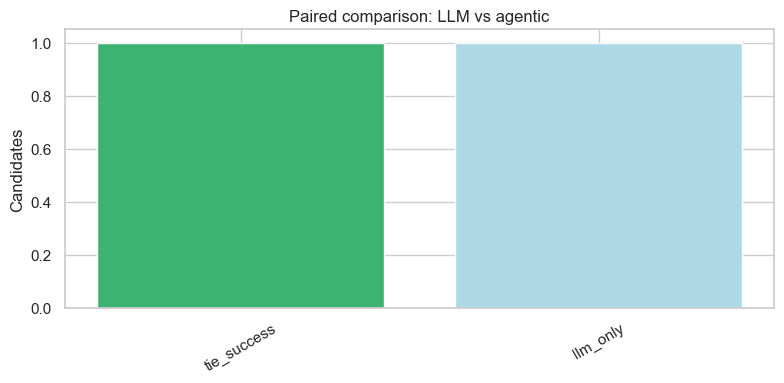

In [2]:
paired = build_paired_comparison(candidates)
print(f'Paired candidate rows: {len(paired)}')
print(paired['winner'].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
paired_win_loss_matrix(paired, ax=ax)
plt.tight_layout()
plt.show()

In [3]:
# McNemar's test on paired candidates where both lanes ran.
# Restrict to rows where both validated_success values are non-NA.
both = paired[
    paired['winner'].isin(['llm_won', 'agentic_won', 'tie_success', 'tie_failure'])
    & paired['llm_validated_success'].notna()
    & paired['agentic_validated_success'].notna()
]
if len(both) >= 5:
    result = mcnemar_test(both['llm_validated_success'], both['agentic_validated_success'])
    print(f"McNemar's: stat={result.statistic:.3f}, p={result.p_value:.4f}, n={result.n}")
    print(f"  odds ratio (llm_wins/agentic_wins) = {result.effect_size:.3f}  [{result.effect_size_label}]")
    print(f"  {result.note}")
else:
    print(f'Too few paired candidates for McNemar test (n={len(both)}, need >=5 discordant pairs).')
    if len(both) > 0:
        print('Descriptive counts only:')
        print(both['winner'].value_counts())


Too few paired candidates for McNemar test (n=1, need >=5 discordant pairs).
Descriptive counts only:
winner
tie_success    1
Name: count, dtype: int64


## 3. Repository-Weighted Comparison

Aggregates success and coverage at the repository level and compares lanes. Falls back to a **repository-blocked bootstrap** (resamples whole repositories, not individual attempts) to account for within-repository correlation when repo-level summaries are unavailable.

In [4]:
if not repos.empty and 'validated_success_rate' in repos.columns:
    display(repos.groupby('lane')[['validated_success_rate', 'mean_coverage_delta', 'mean_mutation_delta']].describe())
else:
    # Fall back to attempt-level repository-blocked bootstrap
    if 'repository_key' in attempts.columns and 'validated_success' in attempts.columns:
        for lane in ('llm', 'agentic'):
            sub = attempts[attempts['lane'] == lane]
            if len(sub) < 2:
                continue
            ci = repository_blocked_bootstrap(sub, lambda df: df['validated_success'].mean())
            print(f"{lane}: success_rate={ci.estimate:.3f} [{ci.lower:.3f}, {ci.upper:.3f}]")

validated_success_rate                                     \
                         count mean  std  min  25%  50%  75%  max   
lane                                                                
agentic                    1.0  1.0  NaN  1.0  1.0  1.0  1.0  1.0   
llm                        2.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   

        mean_coverage_delta            ...                      \
                      count      mean  ...       75%       max   
lane                                   ...                       
agentic                 1.0  0.347826  ...  0.347826  0.347826   
llm                     2.0  0.293478  ...  0.396739  0.500000   

        mean_mutation_delta                                             \
                      count       mean       std        min        25%   
lane                                                                     
agentic                 1.0  30.555556       NaN  30.555556  30.555556   
llm                     2.0   1.420395  1.919629   0.063012   0.741703   

                                          
               50%        75%        max  
lane                                      
agentic  30.555556  30.555556  30.555556  
llm       1.420395   2.099086   2.777778  

[2 rows x 24 columns]

## 4. Attempt-Weighted Comparison

Treats each attempt as an observation and compares success rates and coverage distributions between lanes. Attempts on the same candidate are not independent, so this is a secondary view to the candidate-weighted comparison (Section 7).

Mann-Whitney U on coverage deltas (non-parametric); effect size is Cliff's delta in [-1, 1] (|d| < 0.15 negligible, 0.15-0.33 small, 0.33-0.47 medium, > 0.47 large). VEP rate is reported alongside `validated_success`.

In [5]:
# Self-caveat: how concentrated is the attempt pool across repositories?
# Attempt-weighted numbers below are only as balanced as this distribution.
if 'repo_name' in attempts.columns and len(attempts):
    rs = (attempts['repo_name'].value_counts(normalize=True) * 100).round(1)
    print('Attempt share by repository:')
    for repo, pct in rs.items():
        print(f'  {repo}: {pct:.0f}%')
    if rs.max() >= 50:
        print(f'  -> {rs.idxmax()} dominates ({rs.max():.0f}%); the attempt-weighted '
              'rates below are NOT repository-balanced. See Section 7 (candidate-weighted).')
    print()

if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    table = attempts.groupby('lane')[['validated_success']].agg(['sum', 'count', 'mean'])
    table.columns = ['successes', 'total', 'success_rate']
    # Add VEP rate separately to distinguish passing tests from impactful tests
    if 'validated_evidence_positive' in attempts.columns:
        vep = attempts.groupby('lane')['validated_evidence_positive'].agg(['sum', 'mean'])
        vep.columns = ['vep_count', 'vep_rate']
        table = table.join(vep)
    display(table)

# Mann-Whitney U on coverage_delta (attempt-weighted, not candidate-paired)
if 'lane' in attempts.columns and 'coverage_delta' in attempts.columns:
    llm_d = attempts[attempts['lane'] == 'llm']['coverage_delta'].dropna()
    ag_d  = attempts[attempts['lane'] == 'agentic']['coverage_delta'].dropna()
    if len(llm_d) >= 2 and len(ag_d) >= 2:
        result = mann_whitney_u(llm_d, ag_d)
        print(f"Mann-Whitney U (coverage_delta): stat={result.statistic:.1f}, p={result.p_value:.4f}, n={result.n}")
        print(f"  Cliff's delta = {result.effect_size:.3f}  (>0 = agentic larger; note: attempt-weighted, see Section 7 for candidate-weighted)")


Attempt share by repository:
  TestMap-Example: 60%
  aspectcore-framework: 40%
  -> TestMap-Example dominates (60%); the attempt-weighted rates below are NOT repository-balanced. See Section 7 (candidate-weighted).



,successes,total,success_rate,vep_count,vep_rate
lane,,,,,
agentic,1,2,0.500000,1,0.500000
llm,2,3,0.666667,2,0.666667


Mann-Whitney U (coverage_delta): stat=3.0, p=0.6667, n=4
  Cliff's delta = 0.500  (>0 = agentic larger; note: attempt-weighted, see Section 7 for candidate-weighted)


## 5. Cost-Effectiveness

Runtime and token cost against outcomes. Reports validated successes per minute (attempt time) and per 1k `effective_tokens` (candidate-level: LLM cumulative chain vs agentic total run).

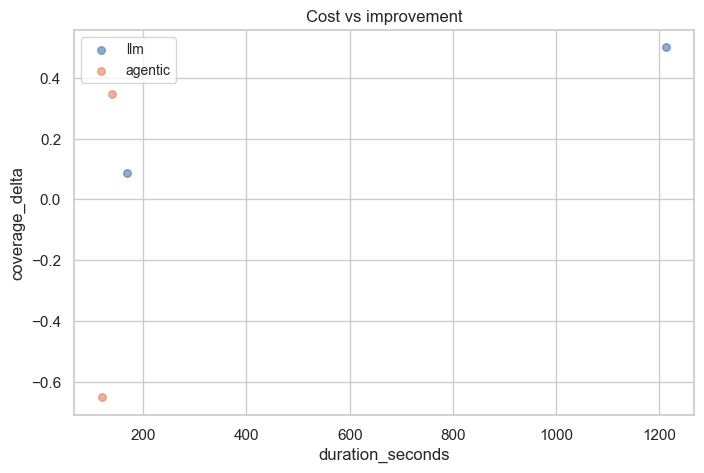

Validated successes per minute:
lane
agentic    0.230221
llm        0.069468
dtype: float64



Validated successes per 1k effective tokens (candidate-level):
lane
agentic    0.002282
llm        0.184843
dtype: float64


In [6]:
if all(c in attempts.columns for c in ['duration_seconds', 'coverage_delta', 'lane']):
    fig, ax = plt.subplots(figsize=(8, 5))
    cost_vs_improvement_scatter(attempts, 'duration_seconds', 'coverage_delta', 'lane', ax=ax)
    plt.show()

# Successes per minute (attempt-level time)
if 'duration_seconds' in attempts.columns and 'validated_success' in attempts.columns:
    spm = attempts.groupby('lane').apply(
        lambda g: g['validated_success'].sum() / (g['duration_seconds'].sum() / 60)
    )
    print('Validated successes per minute:')
    print(spm)

# Successes per 1k effective tokens (candidate-level, lane-fair)
if 'effective_tokens' in candidates.columns and 'any_validated_success' in candidates.columns:
    spk = candidates.groupby('lane').apply(
        lambda g: g['any_validated_success'].sum() / (g['effective_tokens'].sum() / 1000)
        if g['effective_tokens'].sum() > 0 else float('nan')
    )
    print('\nValidated successes per 1k effective tokens (candidate-level):')
    print(spk)

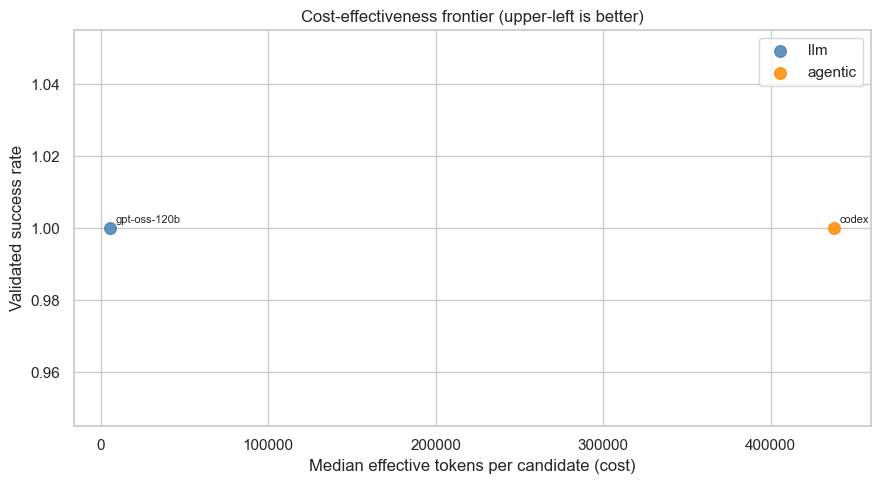

,lane,producer,success_rate,cost,n,on_frontier
0,agentic,codex,1.0,438145.0,1,False
1,llm,gpt-oss-120b,1.0,5410.0,2,True


In [7]:
# RQ4 cost-effectiveness frontier: validated success rate vs token cost per model/tool.
import numpy as np
prod = candidates.copy()
prod['producer'] = prod.apply(lambda r: r['model'] if r['lane'] == 'llm' else r.get('tool_id', r['model']), axis=1)
if {'producer', 'any_validated_success', 'effective_tokens'} <= set(prod.columns):
    grp = (prod.groupby(['lane', 'producer'])
           .agg(success_rate=('any_validated_success', 'mean'),
                cost=('effective_tokens', 'median'),
                n=('any_validated_success', 'size'))
           .reset_index().dropna(subset=['cost']))
    if len(grp):
        frontier = []
        for r in grp.itertuples():
            dominated = ((grp['cost'] <= r.cost) & (grp['success_rate'] >= r.success_rate) &
                         ((grp['cost'] < r.cost) | (grp['success_rate'] > r.success_rate))).any()
            frontier.append(not dominated)
        grp['on_frontier'] = frontier
        fig, ax = plt.subplots(figsize=(9, 5))
        for lane, col in [('llm', 'steelblue'), ('agentic', 'darkorange')]:
            s = grp[grp['lane'] == lane]
            ax.scatter(s['cost'], s['success_rate'], c=col, s=70, alpha=0.85, label=lane)
            for r in s.itertuples():
                ax.annotate(str(r.producer), (r.cost, r.success_rate), fontsize=8,
                            xytext=(4, 4), textcoords='offset points')
        fr = grp[grp['on_frontier']].sort_values('cost')
        if len(fr) > 1:
            ax.plot(fr['cost'], fr['success_rate'], 'k--', alpha=0.5, label='Pareto frontier')
        ax.set_xlabel('Median effective tokens per candidate (cost)')
        ax.set_ylabel('Validated success rate')
        ax.set_title('Cost-effectiveness frontier (upper-left is better)')
        ax.legend()
        plt.tight_layout(); plt.show()
        display(grp.round(3))
    else:
        print('No cost/success data available for the frontier.')
else:
    print('effective_tokens / any_validated_success not available; rebuild datasets.')

## 6. Risk / Change Footprint

Compares what the agentic lane modified beyond the target test file. `changed_files_count` is always present; the per-type risk breakdown (`production_files_changed`, `project_files_changed`, `deleted_files_count`) is exported only for runs produced after the footprint-export change. When those columns are absent (as in this pilot) the breakdown is skipped -- **do not read a missing column as a 0% production-change rate**, which would falsely imply the tool never touches production code. A measured non-zero production-file change rate is a correctness risk.

In [8]:
agentic = attempts[attempts.get('lane', pd.Series()) == 'agentic']
footprint_cols = [c for c in ['changed_files_count', 'production_files_changed',
                               'project_files_changed', 'deleted_files_count'] if c in agentic.columns]
if footprint_cols:
    display(agentic[footprint_cols].describe().T)

# Production/project file change rate
if 'production_files_changed' in agentic.columns:
    rate = (agentic['production_files_changed'].fillna(0) > 0).mean()
    print(f'Agentic production-file change rate: {rate:.1%}')

,count,mean,std,min,25%,50%,75%,max
changed_files_count,2.0,1.5,0.707107,1.0,1.25,1.5,1.75,2.0
production_files_changed,2.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0
project_files_changed,2.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0
deleted_files_count,2.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0


Agentic production-file change rate: 0.0%


## 7. Sensitivity Analyses

Re-runs the comparison at the candidate level (best attempt per candidate per lane) and checks whether attempt-weighted and candidate-weighted rates agree in direction and magnitude.

In [9]:
# Compare attempt-weighted vs candidate-weighted success rates
print('=== Attempt-weighted ===')
if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    agg = attempts.groupby('lane')[['validated_success']].mean()
    if 'validated_evidence_positive' in attempts.columns:
        agg['vep_rate'] = attempts.groupby('lane')['validated_evidence_positive'].mean()
    print(agg)

print('\n=== Candidate-weighted (preferred for primary comparison) ===')
if 'lane' in candidates.columns and 'any_validated_success' in candidates.columns:
    cagg = candidates.groupby('lane')[['any_validated_success']].mean()
    if 'validated_evidence_positive_count' in candidates.columns:
        cagg['vep_rate'] = candidates.groupby('lane').apply(
            lambda g: (g['validated_evidence_positive_count'] > 0).mean()
        )
    print(cagg)


=== Attempt-weighted ===
         validated_success  vep_rate
lane                                
agentic           0.500000  0.500000
llm               0.666667  0.666667

=== Candidate-weighted (preferred for primary comparison) ===
         any_validated_success  vep_rate
lane                                    
agentic                    1.0       1.0
llm                        1.0       1.0


## 8. Outcome Classification by Lane

Shows the full outcome taxonomy broken down by lane, complementing the binary success rates above. Distinguishes ValidatedEvidencePositive (passed + metrics improved), ValidatedLowImpact (passed + no metric improvement), FailedEvidencePositive (test failed but metrics moved), and various failure modes.


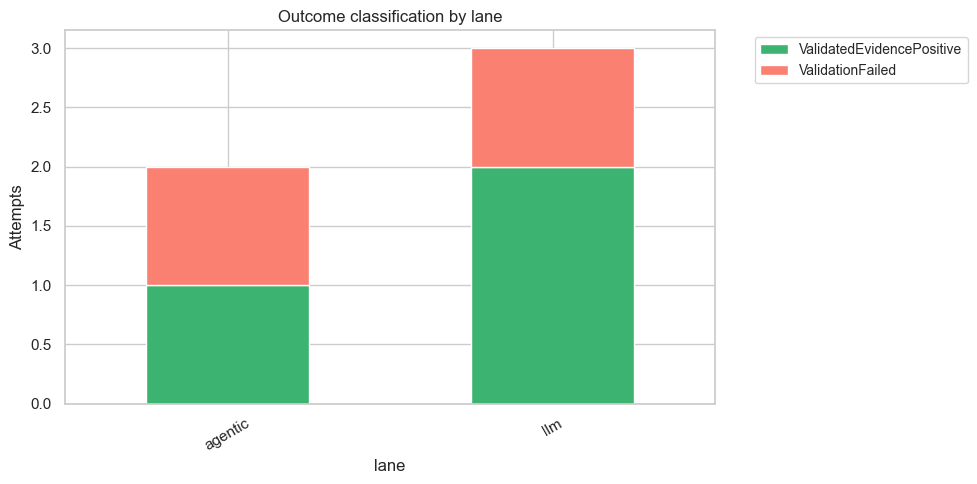

Outcome distribution (%):


outcome_classification,ValidatedEvidencePositive,ValidationFailed
lane,,
agentic,50.0,50.0
llm,66.7,33.3


In [10]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    outcome_classification_bar(attempts, group_col='lane', ax=ax)
    plt.tight_layout()
    plt.show()

    oc_table = attempts.groupby(['lane', 'outcome_classification']).size().unstack(fill_value=0)
    oc_pct = oc_table.div(oc_table.sum(axis=1), axis=0).mul(100)
    print('Outcome distribution (%):')
    display(oc_pct.round(1))
else:
    print('outcome_classification column not found.')

## 9. Code Metrics: Baseline -> Generated Test

Compares structural properties of the **baseline tests** against the **generated tests** (cyclomatic complexity, maintainability index, SLOC, coupling) as a slope chart. Each line is one attempt; the mean overlay shows the typical direction of transformation. Note: this section includes all attempts regardless of outcome.


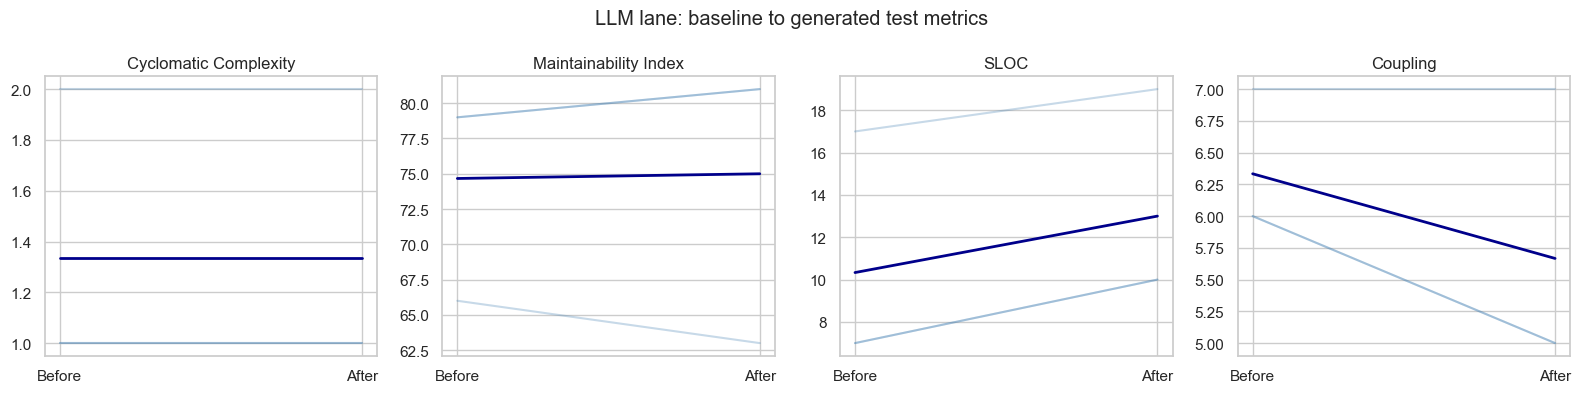

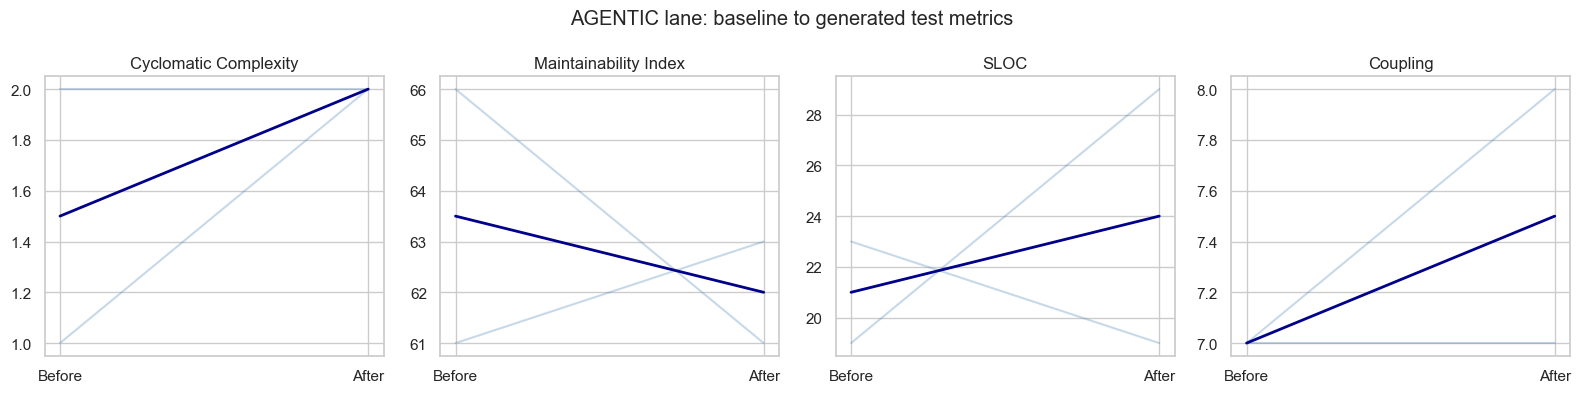

Median metrics by lane:


,baseline_test_cc,generated_test_cc,baseline_test_mi,generated_test_mi,baseline_test_sloc,generated_test_sloc,baseline_test_coupling,generated_test_coupling
lane,,,,,,,,
agentic,1.5,2.0,63.5,62.0,21.0,24.0,7.0,7.5
llm,1.0,1.0,79.0,81.0,7.0,10.0,6.0,5.0


In [11]:
from analysis.plots import before_after_slope

metric_pairs = [
    ('baseline_test_cc',       'generated_test_cc',       'Cyclomatic Complexity'),
    ('baseline_test_mi',       'generated_test_mi',       'Maintainability Index'),
    ('baseline_test_sloc',     'generated_test_sloc',     'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
available = [(b, g, lbl) for b, g, lbl in metric_pairs
             if b in attempts.columns and g in attempts.columns]

if available:
    for lane in ('llm', 'agentic'):
        lane_df = attempts[attempts['lane'] == lane]
        if len(lane_df) == 0:
            continue
        fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4))
        if len(available) == 1:
            axes = [axes]
        for ax, (before_col, after_col, label) in zip(axes, available):
            before_after_slope(lane_df, before_col, after_col, ax=ax)
            ax.set_title(f'{label}')
        plt.suptitle(f'{lane.upper()} lane: baseline to generated test metrics')
        plt.tight_layout()
        plt.show()

# Summary table: median by lane
all_metric_cols = [c for pair in available for c in pair[:2] if c in attempts.columns]
if all_metric_cols and 'lane' in attempts.columns:
    print('Median metrics by lane:')
    display(attempts.groupby('lane')[all_metric_cols].median().round(2))

## 10. Test Smell Comparison: Baseline vs Generated

Counts and categorises test smell instances in the baseline (existing) test class and in the generated test, split by lane. A higher generated smell count relative to baseline suggests the tool is introducing code quality issues alongside the new test.


Baseline smell counts by lane:
         sum  mean  median
lane                      
agentic    2   1.0     1.0
llm        0   0.0     0.0

Generated smell counts by lane:
         sum  mean  median
lane                      
agentic    2  1.00     1.0
llm        5  1.67     2.0



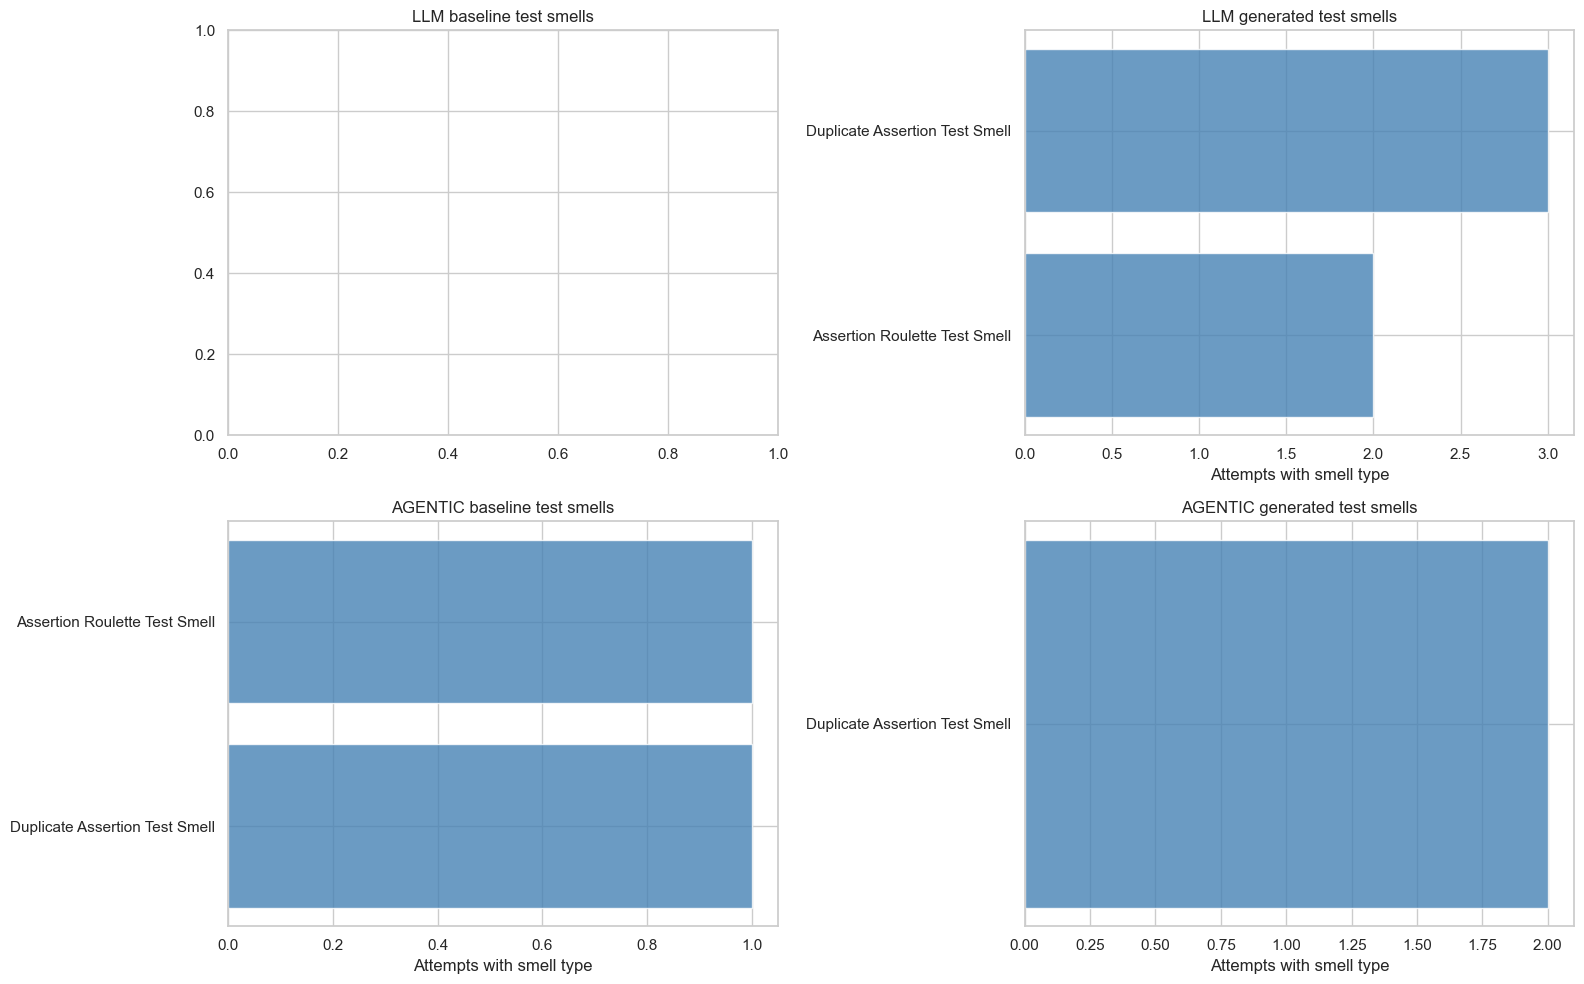

In [12]:
from analysis.plots import smell_type_breakdown

# Smell count summary by lane
for count_col, label in [('baseline_test_smell_count', 'Baseline'), ('generated_test_smell_count', 'Generated')]:
    if count_col in attempts.columns:
        print(f'{label} smell counts by lane:')
        print(attempts.groupby('lane')[count_col].agg(['sum', 'mean', 'median']).round(2))
        print()

# Smell type breakdown by lane
lanes = [l for l in ('llm', 'agentic') if l in attempts['lane'].values]
n_lanes = len(lanes)
if n_lanes > 0:
    fig, axes = plt.subplots(n_lanes, 2, figsize=(16, 5 * n_lanes), squeeze=False)
    for row, lane in enumerate(lanes):
        lane_df = attempts[attempts['lane'] == lane]
        smell_type_breakdown(lane_df, 'baseline_test_smell_types',  ax=axes[row][0])
        axes[row][0].set_title(f'{lane.upper()} baseline test smells')
        smell_type_breakdown(lane_df, 'generated_test_smell_types', ax=axes[row][1])
        axes[row][1].set_title(f'{lane.upper()} generated test smells')
    plt.tight_layout()
    plt.show()

## 11. Timing and Cost by Lane

Median/total duration, generation vs validation phase breakdown, and cost-per-success by lane. Time is attempt-level; token cost uses candidate-level `effective_tokens` (LLM cumulative chain vs agentic total run).

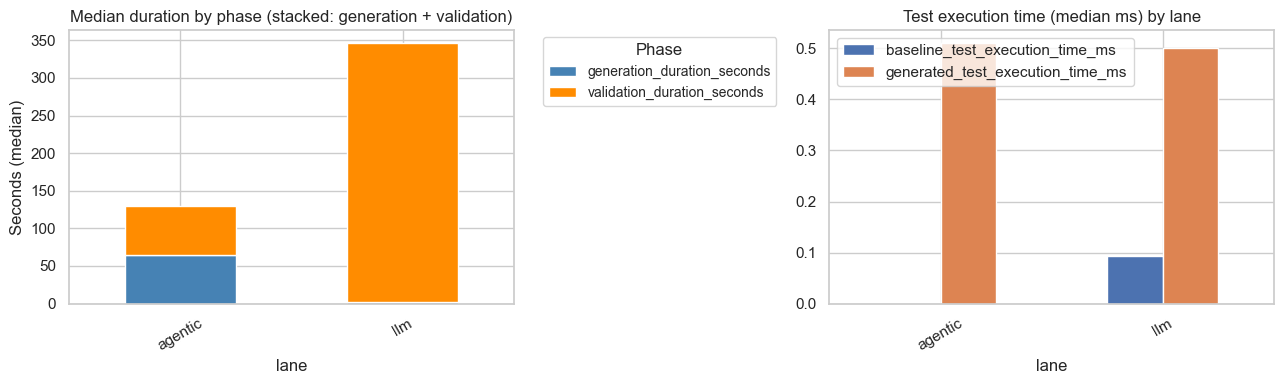

Time cost per validated success (attempt-level):


,total_seconds,attempt_successes,seconds_per_success
lane,,,
agentic,260.6,1.0,260.6
llm,1727.4,2.0,863.7



Token cost per validated success (candidate-level, lane-fair):


,effective_tokens,candidate_successes,tokens_per_success
lane,,,
agentic,438145.0,1.0,438145.0
llm,10820.0,2.0,5410.0


In [13]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(attempts, group_col='lane', ax=axes[0])
axes[0].set_title('Median duration by phase (stacked: generation + validation)')

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in attempts.columns]
if exec_cols:
    attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time (median ms) by lane')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Cost per success: time from attempts, tokens from candidate-level effective_tokens.
if all(c in attempts.columns for c in ['duration_seconds', 'validated_success']):
    time_part = attempts.groupby('lane').apply(lambda g: pd.Series({
        'total_seconds': g['duration_seconds'].sum(),
        'attempt_successes': g['validated_success'].sum(),
        'seconds_per_success': g['duration_seconds'].sum() / max(g['validated_success'].sum(), 1),
    }))
    print('Time cost per validated success (attempt-level):')
    display(time_part.round(1))

if 'effective_tokens' in candidates.columns and 'any_validated_success' in candidates.columns:
    tok_part = candidates.groupby('lane').apply(lambda g: pd.Series({
        'effective_tokens': g['effective_tokens'].sum(),
        'candidate_successes': g['any_validated_success'].sum(),
        'tokens_per_success': g['effective_tokens'].sum() / max(g['any_validated_success'].sum(), 1),
    }))
    print('\nToken cost per validated success (candidate-level, lane-fair):')
    display(tok_part.round(1))